
h = 0.01
x = 0.0   error = 0.0
x = 0.01   error = 0.0
x = 0.02   error = 0.0
x = 0.03   error = 0.0
x = 0.04   error = 0.0
x = 0.05   error = 0.0
x = 0.06   error = 0.0
x = 0.07   error = 0.0
x = 0.08   error = 0.0
x = 0.09   error = 0.0
x = 0.1   error = 0.0
x = 0.11   error = 0.0
x = 0.12   error = 0.0
x = 0.13   error = 0.0
x = 0.14   error = 0.0
x = 0.15   error = 0.0
x = 0.16   error = 0.0
x = 0.17   error = 0.0
x = 0.18   error = 0.0
x = 0.19   error = 0.0
x = 0.2   error = 0.0
x = 0.21   error = 0.0
x = 0.22   error = 0.0
x = 0.23   error = 0.0
x = 0.24   error = 0.0
x = 0.25   error = 0.0
x = 0.26   error = 0.0
x = 0.27   error = 0.0
x = 0.28   error = 0.0
x = 0.29   error = 0.0
x = 0.3   error = 0.0
x = 0.31   error = 0.0
x = 0.32   error = 0.0
x = 0.33   error = 0.0
x = 0.34   error = 0.0
x = 0.35   error = 0.0
x = 0.36   error = 0.0
x = 0.37   error = 0.0
x = 0.38   error = 0.0
x = 0.39   error = 0.0
x = 0.4   error = 0.0
x = 0.41   error = 0.0
x = 0.42   error = 0.0
x = 0.

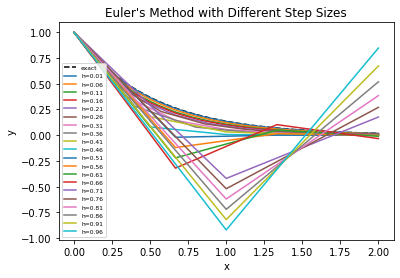

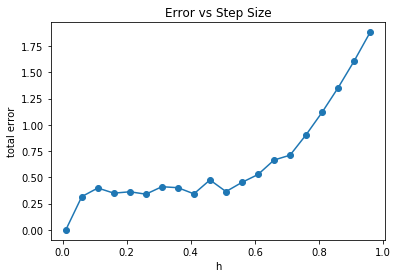

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# interval
x_start = 0
x_end = 2

# function dy/dx = -2y
def f(x, y):
    return -2*y

# exact solution
def exact(x):
    return np.exp(-2*x)

# first run
h_first = 0.01
num_steps = int((x_end - x_start) / h_first)
x_first = np.linspace(x_start, x_end, num_steps + 1)
y_first = np.zeros(num_steps + 1)
y_first[0] = 1

for i in range(num_steps):
    y_first[i+1] = y_first[i] + h_first * f(x_first[i], y_first[i])
    
# step sizes
step_sizes = np.arange(0.01, 1.01, 0.05)

# plot all runs
plt.figure()

# exact solution
x_exact = np.linspace(0, 2, 200)
plt.plot(x_exact, exact(x_exact), 'k--', label='exact')
total_errors = []

for h in step_sizes:
    num_steps = int((x_end - x_start) / h)
    x_vals = np.linspace(x_start, x_end, num_steps + 1)
    y_vals = np.zeros(num_steps + 1)
    y_vals[0] = 1
    
    # euler method
    for i in range(num_steps):
        y_vals[i+1] = y_vals[i] + h * f(x_vals[i], y_vals[i])
        
    # plot
    plt.plot(x_vals, y_vals, label=f'h={round(h,2)}')
    
    # error vs first run
    y_interp = np.interp(x_vals, x_first, y_first)
    errors = np.abs(y_vals - y_interp)
    total_error = np.sum(errors)
    total_errors.append(total_error)
    print("\nh =", round(h,2))
    
    for xi, ei in zip(x_vals, errors):
        print("x =", round(xi, 4), "  error =", round(ei, 6))
        
    print("total error =", total_error)
    
plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method with Different Step Sizes")
plt.legend(fontsize=6)
plt.show()

# error plot
plt.figure()
plt.plot(step_sizes, total_errors, 'o-')
plt.xlabel("h")
plt.ylabel("total error")
plt.title("Error vs Step Size")
plt.show()